Original shape: (1827, 15)
After engineering: (1820, 23)
X shape: (1820, 19)
MAE: 129.38602924556523
RMSE: 153.46903102266646
R2: -0.12428246839922008
Model Accuracy: 22.52747252747253 %
AQI Category Accuracy: 21.978021978021978 %


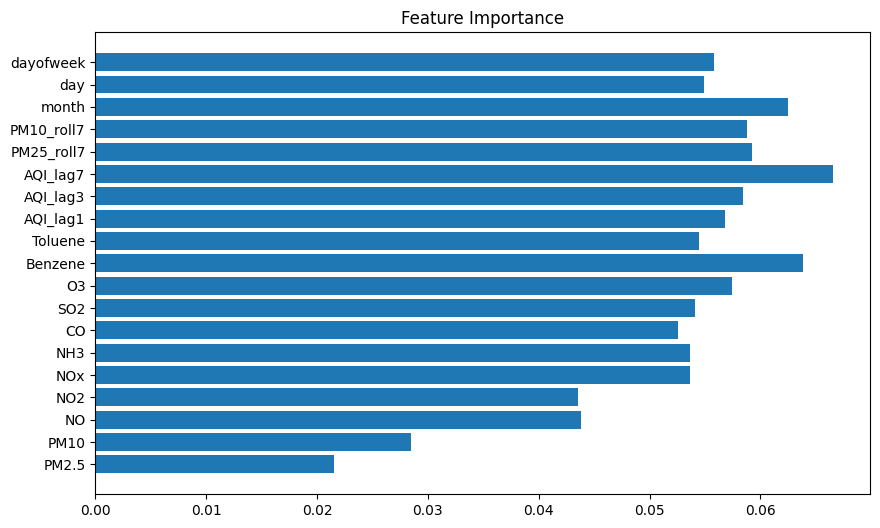

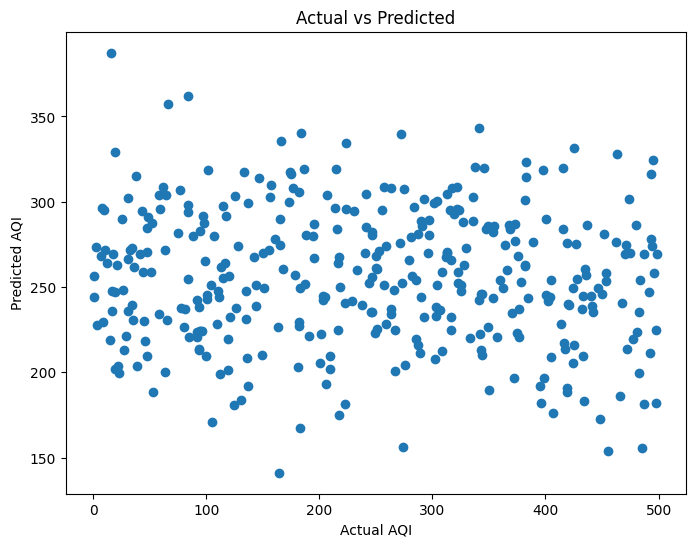

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/cleaned_aqi_final.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Original shape:", df.shape)

# =========================
# FEATURE ENGINEERING
# =========================
df['AQI_lag1'] = df['AQI'].shift(1)
df['AQI_lag3'] = df['AQI'].shift(3)
df['AQI_lag7'] = df['AQI'].shift(7)

df['PM25_roll7'] = df['PM2.5'].rolling(7).mean()
df['PM10_roll7'] = df['PM10'].rolling(7).mean()

df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek

df = df.dropna()

print("After engineering:", df.shape)

# =========================
# FEATURES
# =========================
features = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'AQI_lag1',
    'AQI_lag3',
    'AQI_lag7',
    'PM25_roll7',
    'PM10_roll7',
    'month',
    'day',
    'dayofweek'
]

X = df[features]
y = df['AQI']

print("X shape:", X.shape)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# MODEL
# =========================
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42
)

# =========================
# TRAIN
# =========================
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# =========================
# PREDICT
# =========================
pred = model.predict(X_test)

# =========================
# METRICS
# =========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# =========================
# ACCURACY (±50 AQI tolerance)
# =========================
error = np.abs(y_test.values - pred)

correct = np.sum(error <= 50)

accuracy = (correct / len(error)) * 100

print("Model Accuracy:", accuracy, "%")

# =========================
# AQI CATEGORY ACCURACY
# =========================
def get_category(aqi):
    if aqi <= 50:
        return 0
    elif aqi <= 100:
        return 1
    elif aqi <= 200:
        return 2
    elif aqi <= 300:
        return 3
    elif aqi <= 400:
        return 4
    else:
        return 5

actual_cat = np.array([get_category(x) for x in y_test])
pred_cat = np.array([get_category(x) for x in pred])

cat_acc = np.mean(actual_cat == pred_cat) * 100

print("AQI Category Accuracy:", cat_acc, "%")

# =========================
# FEATURE IMPORTANCE
# =========================
importance = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

# =========================
# ACTUAL VS PREDICTED
# =========================
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted")
plt.show()